In [1]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.clients.fdsn import RoutingClient
from obspy import Stream
from obspy.geodetics import gps2dist_azimuth
from obspy import signal
from obspy import read
import matplotlib.pyplot as plt
import folium
import numpy as np
import json
import pandas as pd
from obspy.clients.fdsn.header import FDSNNoDataException
from scipy.signal import savgol_filter
import os
import folium
import numpy as np
import branca.colormap as cm

from obspy import Stream
from matplotlib.colors import LogNorm

import pandas as pd

Dtmin_Noise=-25
Dtmax_Noise=-5
Dtmin_Pn=-5.
Dtmax_Pn=10.
Dtmin_Sn=-5.
Dtmax_Sn=10.

vLg_max=3.5
vLg_min=3.1
vLg=0.5*(vLg_max+vLg_min)
vPg_max=6.2
vPg_min=5.2
vPg=0.5*(vPg_max+vPg_min)
print(vPg)
#vPg=6.

tminCoda=300.
tmaxCoda=320.
#from new_functions import *
from processing_routines import *
from plotting_routines import *

5.7


In [4]:

Dtmin_Noise=-25
Dtmax_Noise=-5
Dtmin_Pn=-5.
Dtmax_Pn=10.
Dtmin_Sn=-5.
Dtmax_Sn=10.

vLg_max=3.5
vLg_min=3.1
vLg=0.5*(vLg_max+vLg_min)
vPg_max=6.2
vPg_min=5.2
vPg=0.5*(vPg_max+vPg_min)
print(vPg)
#vPg=6.

tminCoda=300.
tmaxCoda=320.

event_name ='Nice 2025'



if event_name == 'Nice 2025':
    start = UTCDateTime("2025-03-18T17:40:00")
    end = UTCDateTime("2025-03-18T17:50:00")


minlat = 37
maxlat = 50.0
minlon = -5
maxlon = 17
minmag = 3.5


events_list = Client("EMSC").get_events(
    minlatitude=minlat,
    maxlatitude=maxlat,
    minlongitude=minlon,
    maxlongitude=maxlon,
    minmagnitude=minmag,
    starttime=start,
    endtime=end
)
print("\nFound %s event(s) from EMSC Data Center:\n" % len(events_list))
print(events_list.__str__(print_all=True))



eqo = events_list[0].origins[0]
eq_start = eqo.time
eq_mag = events_list[0].magnitudes[0].mag
print(type(eq_start))
t_duration=500. #length of window to request
eq_end = eq_start + t_duration
eq_lat=eqo.latitude
print((eq_end))
eq_lon=eqo.longitude
eq_epi=(eq_lat,eq_lon)


degmin=1.9
degmax=10.
start = eq_start -25
end = eq_end
datacenters=['RESIF','ODC','ETH','INGV','GEOFON', 'IRIS', 'ICGC','LMU','BGR']
st_all, stations_all, plot = big_downloader2(datacenters,start,end,eq_lon,eq_lat,degmin,degmax,directory='/home/schreinl/Stage/Data1/',plot=True)
plot

5.7

Found 1 event(s) from EMSC Data Center:

1 Event(s) in Catalog:
2025-03-18T17:45:01.100000Z | +43.860,   +7.300 | 4.0  ml | manual
<class 'obspy.core.utcdatetime.UTCDateTime'>
2025-03-18T17:53:21.100000Z
Earthquake at 2025-03-18T17:45:01.100000Z with magnitude 4.0


Processing stations of BGR: 100%|██████████| 146/146 [00:12<00:00, 11.36it/s]


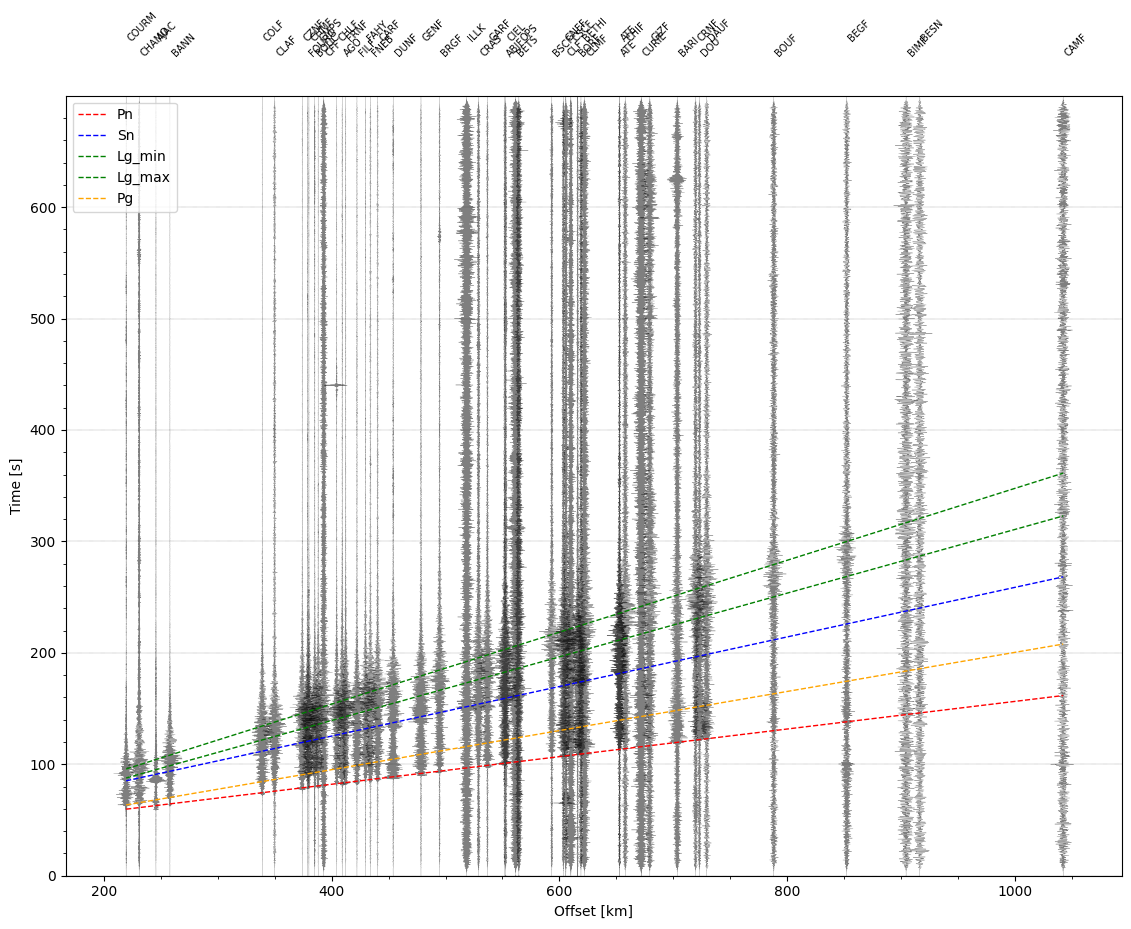

In [59]:
fmin=1
fmax=7
f0=0.5*(fmin+fmax)

st_plot_filt_all=st_all.copy()
st_plot_filt_all.filter("bandpass", freqmin=fmin, freqmax=fmax)

st_test = st_plot_filt_all[0:50]
stations_test = stations_all[0:50]

for i,tr in enumerate(st_plot_filt_all):
    if tr.stats.station == 'TAMIE':
        st_test += tr
        stations_test += stations_all[i]
        
        

plot, st_Lg0 = plot_record_section(st_plot_filt_all[0:50], stations_all[0:50], eq_lat, 
eq_lon, eq_start, tracehodo=True, v_Lg_min=vLg_min, v_Lg_max=vLg_max, 
v_Pg=vPg)


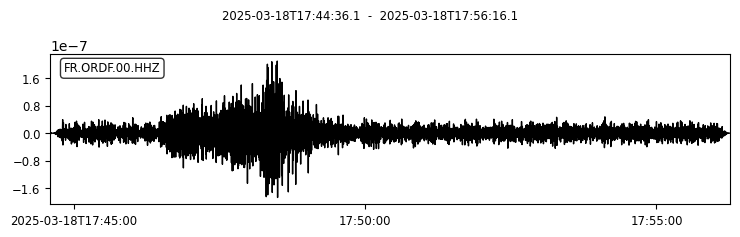

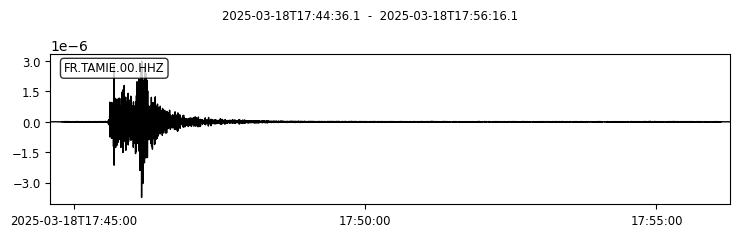

685.0038357498548


In [54]:
st_plot_filt_all[90].plot()
for i,tr in enumerate(st_plot_filt_all):
    if tr.stats.station == 'TAMIE':
        Bouf=tr
        distance = stations_all[i][5]

Bouf.plot()
 

print(distance/1000)

In [56]:


t1 = (distance/1000)/vLg_max
t2 = (distance/1000)/vLg_min
print(t1)
print(t2)




195.71538164281566
220.9689792741467


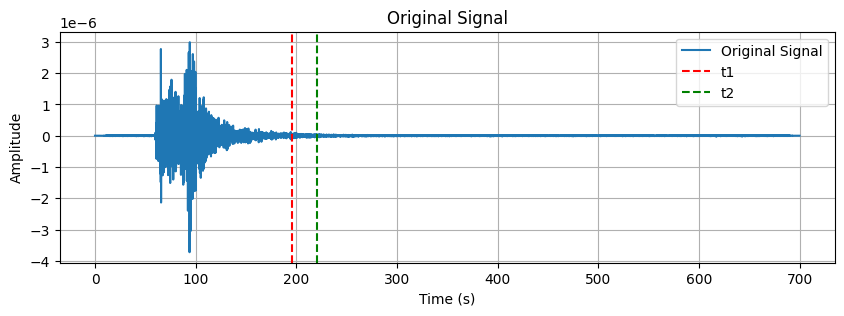

In [58]:
timeseries = Bouf.data
dt = Bouf.stats.delta
t = np.arange(0, len(timeseries)) * dt
t1 = (distance/1000)/vLg_max
t2 = (distance/1000)/vLg_min

plt.figure(figsize=(10, 3))
plt.plot(t, timeseries, label='Original Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Original Signal')
plt.axvline(x=t1, color='r', linestyle='--', label='t1')

plt.axvline(x=t2, color='g', linestyle='--', label='t2')
plt.legend()
plt.grid()
plt.show()


In [ ]:
#stations_with_amps: 
#net (0), sta (1), lat (2), lon (3), elev (4) , dist(5), az(6), 
# t_Pn (7), t_Sn (8), t_Pg(9), A_Pn (10), A_Sn (11), A_Lg(12), A_Coda(13), A_Noise(14), A_pg(15)

stations_with_amps=calc_amps(stations_all, 
st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min, vPg_max, tminCoda, tmaxCoda, Dtmin_Noise, Dtmax_Noise,eq_start)



def select_ratio(wavecode, stations_with_amps):
    '''
    this only works when the stations_with amps file is in this format:
    net (0), sta (1), lat (2), lon (3), elev (4) , dist(5), az(6), 
    t_Pn (7), t_Sn (8), t_Pg(9), A_Pn (10), A_Sn (11), A_Lg(12), A_Coda(13), A_Noise(14), A_pg(15)

    '''
    distDraw=stations_with_amps[:,5].astype(float)/1000.
    azDraw=stations_with_amps[:,6].astype(float) 

    if wavecode == 'Pn' :
        Amp_Draw=stations_with_amps[:,10].astype(float)
    elif wavecode == 'Sn' :
        Amp_Draw=stations_with_amps[:,11].astype(float)
    elif wavecode == 'Lg' :
        Amp_Draw=stations_with_amps[:,12].astype(float)  
    elif wavecode == 'Coda' :
        Amp_Draw=stations_with_amps[:,13].astype(float)    
    elif wavecode == 'Noise' :
        Amp_Draw=stations_with_amps[:,14].astype(float) 
    elif wavecode == 'Pg' :
        Amp_Draw=stations_with_amps[:,15].astype(float)
    elif wavecode== 'Pg_Coda':
        Amp_Draw=np.divide(stations_with_amps[:,15].astype(float),stations_with_amps[:,13].astype(float))
    elif wavecode == 'Lg_Coda' :
        Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,13].astype(float))
    elif wavecode == 'Lg_Pn' :
        Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,10].astype(float))
    elif wavecode == 'Lg_Pg' :
        Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,15].astype(float))
    elif wavecode == 'Lg_Sn' :
        Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,11].astype(float))
    elif wavecode == 'Pn_Coda' :
        Amp_Draw=np.divide(stations_with_amps[:,10].astype(float),stations_with_amps[:,13].astype(float))
    elif wavecode == 'Sn_Coda' :
        Amp_Draw=np.divide(stations_with_amps[:,11].astype(float),stations_with_amps[:,13].astype(float))
    elif wavecode == 'Lg_Noise' :
        Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,14].astype(float))
    elif wavecode == 'Coda_Noise' :
        Amp_Draw=np.divide(stations_with_amps[:,13].astype(float),stations_with_amps[:,14].astype(float))
    else:
        Amp_Draw = np.zeros(stations_with_amps.shape[0])
        print('wavecode not recognized')
    Amp_Draw[np.isnan(Amp_Draw)] = 0    
    Amp_Draw[np.isinf(Amp_Draw)] = 0
    return Amp_Draw



wavecode='Lg_Coda'

distDraw=stations_with_amps[:,5].astype(float)/1000.
azDraw=stations_with_amps[:,6].astype(float) 

if wavecode == 'Pn' :
    Amp_Draw=stations_with_amps[:,10].astype(float)
elif wavecode == 'Sn' :
    Amp_Draw=stations_with_amps[:,11].astype(float)
elif wavecode == 'Lg' :
    Amp_Draw=stations_with_amps[:,12].astype(float)  
elif wavecode == 'Coda' :
    Amp_Draw=stations_with_amps[:,13].astype(float)    
elif wavecode == 'Noise' :
    Amp_Draw=stations_with_amps[:,14].astype(float) 
elif wavecode == 'Pg' :
    Amp_Draw=stations_with_amps[:,15].astype(float)
elif wavecode == 'Lg_Coda' :
    Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,13].astype(float))
elif wavecode == 'Lg_Pn' :
    Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,10].astype(float))
elif wavecode == 'Lg_Pg' :
    Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,15].astype(float))
elif wavecode == 'Lg_Sn' :
    Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,11].astype(float))
elif wavecode == 'Pn_Coda' :
    Amp_Draw=np.divide(stations_with_amps[:,10].astype(float),stations_with_amps[:,13].astype(float))
elif wavecode == 'Sn_Coda' :
    Amp_Draw=np.divide(stations_with_amps[:,11].astype(float),stations_with_amps[:,13].astype(float))
elif wavecode == 'Lg_Noise' :
    Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,14].astype(float))
elif wavecode == 'Coda_Noise' :
    Amp_Draw=np.divide(stations_with_amps[:,13].astype(float),stations_with_amps[:,14].astype(float))
else:
    Amp_Draw = np.zeros(stations_with_amps.shape[0])
    print('wavecode not recognized')
Amp_Draw[np.isnan(Amp_Draw)] = 0    
Amp_Draw[np.isinf(Amp_Draw)] = 0

print(Amp_Draw.shape)
print(stations_with_amps.shape)


if stations_with_amps[1] == 'TAMIE':
    Bouf=stations_with_amps[1]
    Bouf.plot()


(758,)
(758, 16)


/tmp/ipykernel_20279/335263209.py:77: RuntimeWarning: invalid value encountered in divide
  Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,13].astype(float))


In [43]:
wavecode='Lg_Noise'

Amp_Draw = select_ratio(wavecode, stations_with_amps)
if Amp_Draw is not None:
    print()
    plot =plot_stations_amps(stations_with_amps, 1, 0.7, Amp_Draw, origin=[eq_lat,eq_lon], zoom=5, forcescale=False)
plot

/tmp/ipykernel_20279/335263209.py:47: RuntimeWarning: invalid value encountered in divide
  Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,14].astype(float))
